### ETTh1 — dataset overview and link to CycleNet's assumptions

Before training any model we look at the dataset used in `02_cyclenet_real_dataset.ipynb`. The goal of this notebook is twofold: introduce ETTh1 (what the columns are, what time range it covers) and check whether the **single property CycleNet relies on** — the presence of a *stable* periodic pattern — actually holds on this data.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


#### 1. What is ETTh1?

**ETTh1** (Electricity Transformer Temperature, hourly, station 1) is one of the standard multivariate forecasting benchmarks used in the CycleNet paper. It records the operating state of an electricity transformer over roughly two years at hourly resolution. Each row is one hour and contains seven channels:

| Column | Meaning |
|---|---|
| `HUFL` | High UseFul Load |
| `HULL` | High UseLess Load |
| `MUFL` | Middle UseFul Load |
| `MULL` | Middle UseLess Load |
| `LUFL` | Low UseFul Load |
| `LULL` | Low UseLess Load |
| `OT` | **Oil Temperature** — the forecasting target |

In notebook 02 we use the multivariate setup (`features="M"`), so the model receives and predicts all seven channels jointly.


In [12]:
ROOT_PATH = Path("../paper_code/CycleNet/dataset")
DATA_PATH = ROOT_PATH / "ETTh1.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()

print("Shape:        ", df.shape)
print("Time range:   ", df.index.min(), "->", df.index.max())
print("Sampling step:", df.index[1] - df.index[0])
print("Channels:     ", list(df.columns))
df.head()


Shape:         (17420, 7)
Time range:    2016-07-01 00:00:00 -> 2018-06-26 19:00:00
Sampling step: 0 days 01:00:00
Channels:      ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


About 17k hourly rows, ~24 months. Following the paper, notebook 02 uses a chronological split of 12 / 4 / 4 months for train / val / test, with `StandardScaler` fit only on the training portion.

#### 2. Does ETTh1 exhibit a stable periodic pattern?

CycleNet is justified by the assumption that the time series contains a periodic component stable enough that a small learnable table (`RecurrentCycle`) can capture it. We check this in two cheap ways: direct visualization of a few days/weeks, and the autocorrelation function.


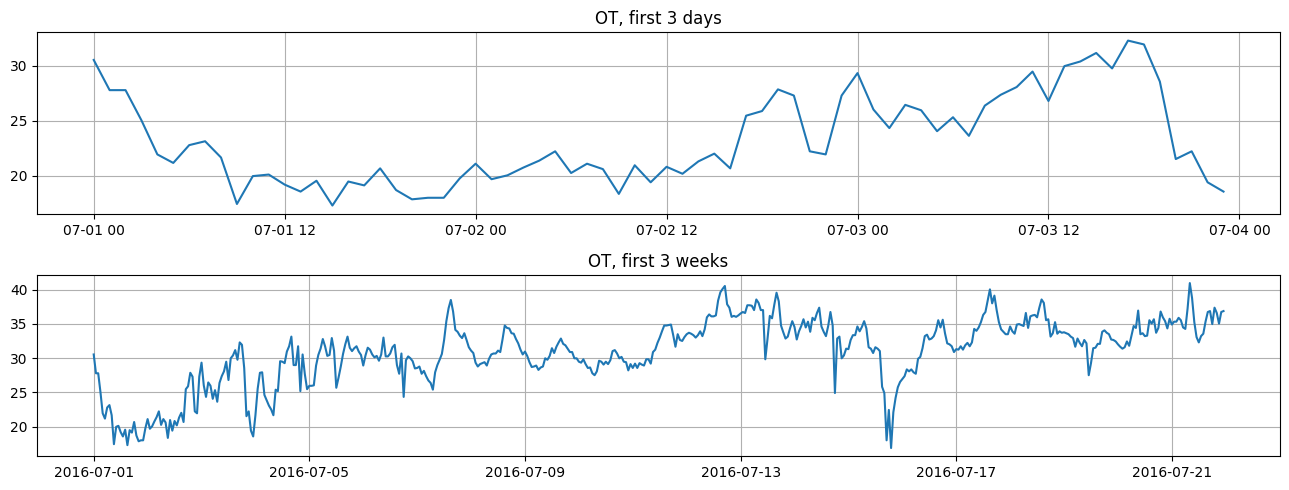

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5))

axes[0].plot(df["OT"].iloc[:24 * 3])
axes[0].set_title("OT, first 3 days")
axes[0].grid(True)

axes[1].plot(df["OT"].iloc[:24 * 7 * 3])
axes[1].set_title("OT, first 3 weeks")
axes[1].grid(True)

plt.tight_layout()
plt.show()


There is a daily pattern in the data: about every 24 hours the series shows a similar rise and fall. The same general shape also repeats across weeks, although the signal is noisy. In the 3-day view, this looks more like a slow overall drift with a small daily fluctuation rather than a perfectly repeating pattern. This is exactly the type of behavior CycleNet is meant to model with its cycle table.

To measure this more clearly, we use the autocorrelation function (ACF). If a signal has a strong repeating cycle with period `p`, the ACF should rise again at lags `p, 2p, 3p, …` and fall in between. The size of these oscillations shows how much of the data is explained by the cycle.

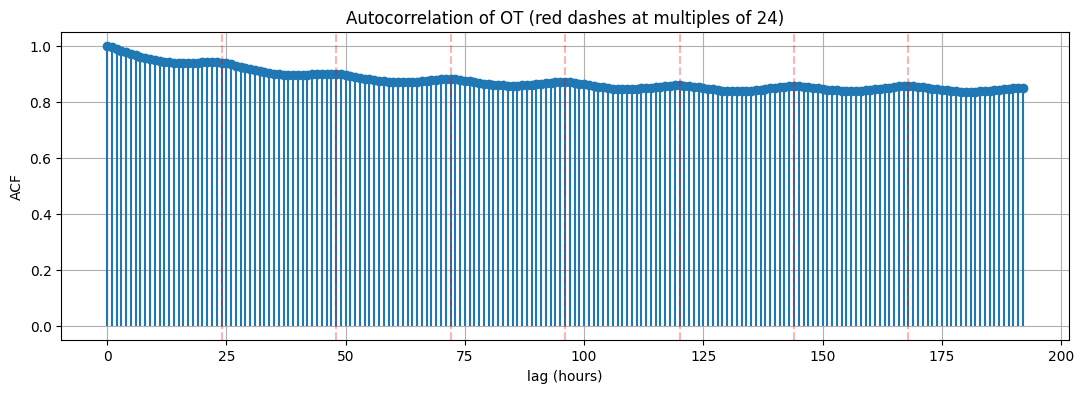

In [14]:
def acf(x, max_lag):
    x = np.asarray(x, dtype=float) - np.mean(x)
    denom = (x * x).sum()
    return np.array([1.0 if k == 0 else (x[:-k] * x[k:]).sum() / denom for k in range(max_lag + 1)])

max_lag = 24 * 8
plt.figure(figsize=(13, 4))
plt.stem(np.arange(max_lag + 1), acf(df["OT"].values, max_lag), basefmt=" ")
for k in [24, 48, 72, 96, 120, 144, 168]:
    plt.axvline(k, color="red", alpha=0.3, linestyle="--")
plt.title("Autocorrelation of OT (red dashes at multiples of 24)")
plt.xlabel("lag (hours)")
plt.ylabel("ACF")
plt.grid(True)
plt.show()


The ACF decays slowly and remains high (~0.85 at lag 190), showing strong persistence and trend, which is expected for oil temperature data. The 24-hour cycle appears only as small peaks at multiples of 24, so the daily pattern is real but weak compared to the trend. A weekly cycle near 168 may exist, but the evidence is unclear.

This still supports using `cycle_len = 24` as the default in notebook 02, while `{12, 48, 168}` remain reasonable alternatives. Since the ACF is dominated by trend rather than periodicity, the cycle table explains only part of the variance; most structure is handled by instance normalization and the backbone model.

#### 3. Is the cycle stable across train / val / test?

CycleNet's mechanism only generalizes if the daily shape on the training segment is still meaningful on validation and test. We compute the average value at each hour-of-day separately on the three chronological splits and compare. This empirical "hour-of-day mean" is exactly what `RecurrentCycle.data` is asked to learn during training.


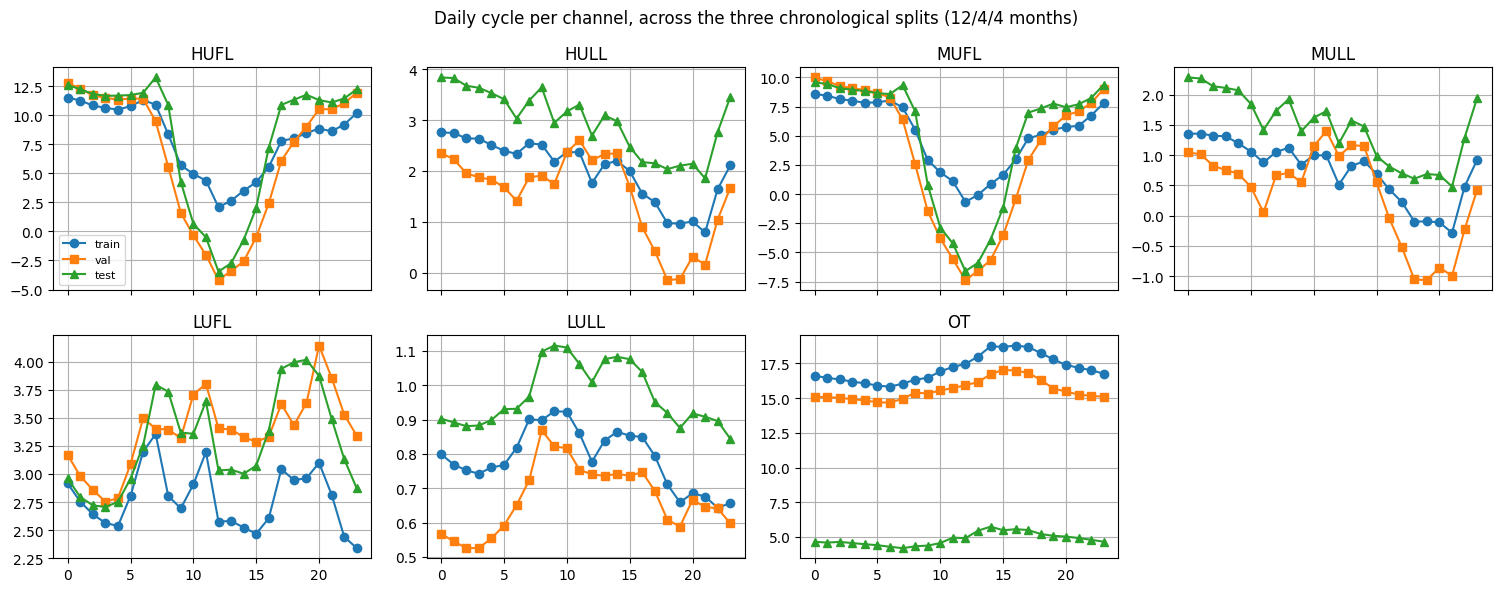

In [15]:
train_end = 24 * 30 * 12             # 12 months
val_end   = train_end + 24 * 30 * 4  # +4 months
test_end  = val_end   + 24 * 30 * 4  # +4 months (matches the official ETT loader: 12/4/4)

hour = df.index.hour.values
cycle_len = 24

def cycle_per_segment(values, hours):
    return np.stack([values[hours == h].mean(axis=0) for h in range(cycle_len)], axis=0)

vals = df.values
cycle_train = cycle_per_segment(vals[:train_end],            hour[:train_end])
cycle_val   = cycle_per_segment(vals[train_end:val_end],     hour[train_end:val_end])
cycle_test  = cycle_per_segment(vals[val_end:test_end],      hour[val_end:test_end])

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
axes = axes.ravel()
for i, ch in enumerate(df.columns):
    axes[i].plot(cycle_train[:, i], marker="o", label="train")
    axes[i].plot(cycle_val[:, i],   marker="s", label="val")
    axes[i].plot(cycle_test[:, i],  marker="^", label="test")
    axes[i].set_title(ch)
    axes[i].grid(True)
    if i == 0:
        axes[i].legend(fontsize=8)
axes[-1].axis("off")
plt.suptitle("Daily cycle per channel, across the three chronological splits (12/4/4 months)")
plt.tight_layout()
plt.show()


The daily cycle keeps the same timing across train, validation, and test: peaks and troughs happen at the same hours. For cleaner channels like HUFL and MUFL, the cycle shape is almost identical across all splits. Noisier channels still follow the same general pattern, but with more variation and higher values in the test split.

Each channel also has its own distinct cycle shape, which is why CycleNet learns a separate cycle for every channel instead of using one shared pattern.

The main exception is OT: its test split is much lower than train and validation and has a smaller amplitude, showing a strong distribution shift. Since these are raw values before normalization, this is exactly the kind of change that RevIN-style instance normalization is meant to handle. By normalizing each window, the level and amplitude differences are reduced so the daily cycles align better before the learned cycle is applied.

#### 4. Takeaways for the experiments in notebook 02

- ETTh1 shows a **clear but weak 24-hour cycle**: the ACF is dominated by trend / slow drift, and the daily pattern only appears as small peaks at multiples of 24. CycleNet's assumption is satisfied in the qualitative sense, but the cycle alone explains a limited share of the variance — most of the structure is left to RevIN-style normalization and the backbone model.
- `cycle_len = 24` is the data-driven choice (visible daily peaks in the ACF and in the hour-of-day averages); `{12, 48, 168}` cover the natural alternatives explored as ablations (sub-period, clean multiple, possible weekly cycle whose evidence in the ACF is unclear).
- `seq_len = 96` (four full days) guarantees that the input window always spans several full cycles, so the model is never forced to extrapolate a period it has not seen.
- The daily cycle has the **same phase** across the three chronological splits but its **level and amplitude shift** (especially on OT). This is exactly the regime RevIN is designed for: per-window normalization removes those shifts before the cycle table is applied.
- The cycle shape **differs across channels** $\rightarrow$ multivariate setup (`features="M"`) with a per-channel cycle table (`[cycle_len, num_channels]`) is the right configuration; a shared scalar cycle would be wrong.
